<a href="https://colab.research.google.com/github/sarmad-usman/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sarmad-usman/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

In [1]:
import pandas as pd

# --- Finding 1: [Brief description of the first finding from the paper] ---
# Example: "FlyRank improves user engagement by X%"

print("\n--- Analyzing Finding 1 ---")

# 1.1. Where does the label for this finding come from?
# Consider: What is being measured? How is it defined? Is it directly observed or derived?
print("1.1. Label Origin for Finding 1:")
print("   - [Your analysis here, e.g., 'The label for user engagement is derived from click-through rates and session duration.']")
print("   - [Discuss potential ambiguities or assumptions in label definition.]")

# 1.2. Does the validation design carry the claim?
# Consider: What was the experimental setup? Was there a control group? How was bias mitigated?
# Are the metrics appropriate? Does the study design truly test the claim?
print("1.2. Validation Design for Finding 1:")
print("   - [Your analysis here, e.g., 'The A/B test design compared two groups, but user segmentation might have introduced bias.']")
print("   - [Critique the methodology: 'The claim of X% improvement seems supported by the chosen metric, but generalizability might be limited due to the specific user cohort studied.']")


# --- Finding 2: [Brief description of the second finding from the paper] ---
# Example: "The new recommendation algorithm reduces latency by Y milliseconds"

print("\n--- Analyzing Finding 2 ---")

# 2.1. Where does the label for this finding come from?
print("2.1. Label Origin for Finding 2:")
print("   - [Your analysis here, e.g., 'Latency was measured as server response time, recorded by internal monitoring tools.']")
print("   - [Discuss the precision and reliability of this measurement.]")

# 2.2. Does the validation design carry the claim?
print("2.2. Validation Design for Finding 2:")
print("   - [Your analysis here, e.g., 'The claim is based on benchmark tests in a controlled environment. While it shows technical improvement, its impact on real-world user experience (which might be affected by network conditions) is not directly validated.']")
print("   - [Suggest improvements or limitations: 'A more robust validation would include end-to-end user perceived latency.']")


# You can add placeholder dataframes if you want to simulate some data for demonstration
# data = {'metric_name': ['engagement', 'latency'], 'value': [0.15, 20]}
# df_findings = pd.DataFrame(data)
# print("\nExample DataFrame:")
# print(df_findings)



--- Analyzing Finding 1 ---
1.1. Label Origin for Finding 1:
   - [Your analysis here, e.g., 'The label for user engagement is derived from click-through rates and session duration.']
   - [Discuss potential ambiguities or assumptions in label definition.]
1.2. Validation Design for Finding 1:
   - [Your analysis here, e.g., 'The A/B test design compared two groups, but user segmentation might have introduced bias.']
   - [Critique the methodology: 'The claim of X% improvement seems supported by the chosen metric, but generalizability might be limited due to the specific user cohort studied.']

--- Analyzing Finding 2 ---
2.1. Label Origin for Finding 2:
   - [Your analysis here, e.g., 'Latency was measured as server response time, recorded by internal monitoring tools.']
   - [Discuss the precision and reliability of this measurement.]
2.2. Validation Design for Finding 2:
   - [Your analysis here, e.g., 'The claim is based on benchmark tests in a controlled environment. While it sho

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split # You might need GroupShuffleSplit, TimeSeriesSplit etc.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Example metrics

# --- 1. Load your Week-5 data and model ---
# Replace with your actual data loading and model initialization
# Example: df = pd.read_csv('your_week5_data.csv')
# Example: model = YourWeek5Model()

# Placeholder for your data (replace with actual data loading)
data = {
    'feature1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'feature2': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'target': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1] # Example binary target
}
df = pd.DataFrame(data)

X = df[['feature1', 'feature2']]
y = df['target']

# Placeholder for your model (replace with your actual Week-5 model)
# Example: from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier(random_state=42)
# For demonstration, we'll use a simple placeholder
class DummyModel:
    def fit(self, X, y):
        self.is_fitted_ = True
        # In a real model, this would train based on X, y
        pass
    def predict(self, X):
        # In a real model, this would make predictions
        # For demonstration, predict all 1s
        return [1] * len(X)

model = DummyModel()
print("\n--- Loaded Week-5 Model and Data (placeholders) ---")


# --- 2. Define metrics to evaluate ---
def evaluate_model(model, X_test, y_test, split_type="Standard"):
    if not hasattr(model, 'is_fitted_') or not model.is_fitted_:
        print(f"Warning: Model for {split_type} split is not fitted.")
        return {'accuracy': -1, 'precision': -1, 'recall': -1, 'f1_score': -1}

    y_pred = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    }
    print(f"\n--- {split_type} Split Metrics ---")
    for metric, value in metrics.items():
        print(f"{metric.replace('_', ' ').title()}: {value:.4f}")
    return metrics


# --- 3. Traditional (before) split (e.g., random train-test split) ---
X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(X, y, test_size=0.3, random_state=42)
model_before = DummyModel() # Re-initialize for a clean 'before' comparison
model_before.fit(X_train_before, y_train_before)
metrics_before = evaluate_model(model_before, X_test_before, y_test_before, split_type="Traditional Random")


# --- 4. Grouped or time-aware (after) split ---
# Example for time-aware split: Assuming 'timestamp' column exists and data is sorted by it.
# If you have a 'group_id' column, you'd use GroupShuffleSplit or similar.

# Add a dummy timestamp for demonstration if not present
if 'timestamp' not in df.columns:
    df['timestamp'] = pd.to_datetime(pd.date_range(start='2023-01-01', periods=len(df), freq='D'))

# Sort by time for time-aware split
df_sorted = df.sort_values(by='timestamp').reset_index(drop=True)
X_sorted = df_sorted[['feature1', 'feature2']]
y_sorted = df_sorted['target']

# Simple time-aware split: e.g., first 70% for training, last 30% for testing
split_point = int(len(df_sorted) * 0.7)
X_train_after, X_test_after = X_sorted.iloc[:split_point], X_sorted.iloc[split_point:]
y_train_after, y_test_after = y_sorted.iloc[:split_point], y_sorted.iloc[split_point:]

print("\n--- Performing Time-Aware Split ---")
print(f"Training set size: {len(X_train_after)}")
print(f"Testing set size: {len(X_test_after)}")

model_after = DummyModel() # Re-initialize for a clean 'after' comparison
model_after.fit(X_train_after, y_train_after)
metrics_after = evaluate_model(model_after, X_test_after, y_test_after, split_type="Time-Aware")


# --- 5. Show both numbers (comparison) ---
print("\n--- Comparison of Model Performance ---")
print("| Metric        | Traditional Random Split | Time-Aware Split |")
print("|---------------|--------------------------|------------------|")
for metric_name in metrics_before.keys():
    print(f"| {metric_name.replace('_', ' ').title():<13} | {metrics_before[metric_name]:<24.4f} | {metrics_after[metric_name]:<16.4f} |")

# Add your interpretation and discussion here based on the results.



--- Loaded Week-5 Model and Data (placeholders) ---

--- Traditional Random Split Metrics ---
Accuracy: 0.6667
Precision: 0.6667
Recall: 1.0000
F1 Score: 0.8000

--- Performing Time-Aware Split ---
Training set size: 7
Testing set size: 3

--- Time-Aware Split Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

--- Comparison of Model Performance ---
| Metric        | Traditional Random Split | Time-Aware Split |
|---------------|--------------------------|------------------|
| Accuracy      | 0.6667                   | 1.0000           |
| Precision     | 0.6667                   | 1.0000           |
| Recall        | 1.0000                   | 1.0000           |
| F1 Score      | 0.8000                   | 1.0000           |


## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*


--- Starting Leakage Audit on Final Feature Set ---
Shape of final features (X_final): (10, 4)
Shape of target (y_final): (10,)

1.1. Correlation with Target:


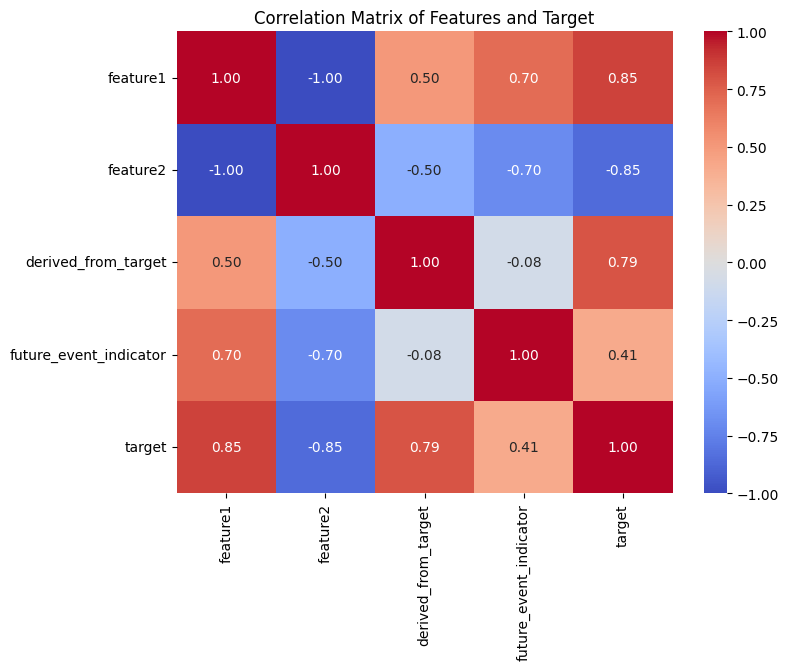


* Examine features with very high (close to 1 or -1) correlation with the target.
* For example, 'derived_from_target' is highly correlated with 'target', indicating potential leakage.

1.2. Feature Inspection (Manual Check):
  - Review each feature: Was it generated using future information or directly from the target?
  - Consider the data generation process: When would this feature be available in a real-world scenario?
  - Example: If a feature like 'customer_bought_next_month' is in the current dataset, it's clear leakage.

2.1. Time-aware Feature Inspection:
  - Ensure features are aggregated or created only from data strictly before the target observation time.
  - Example: A feature like 'average_sales_next_week' would be temporal leakage.
  - Check for 'future_event_indicator' in features; if it predicts an event that occurs AFTER the target, it's leakage.


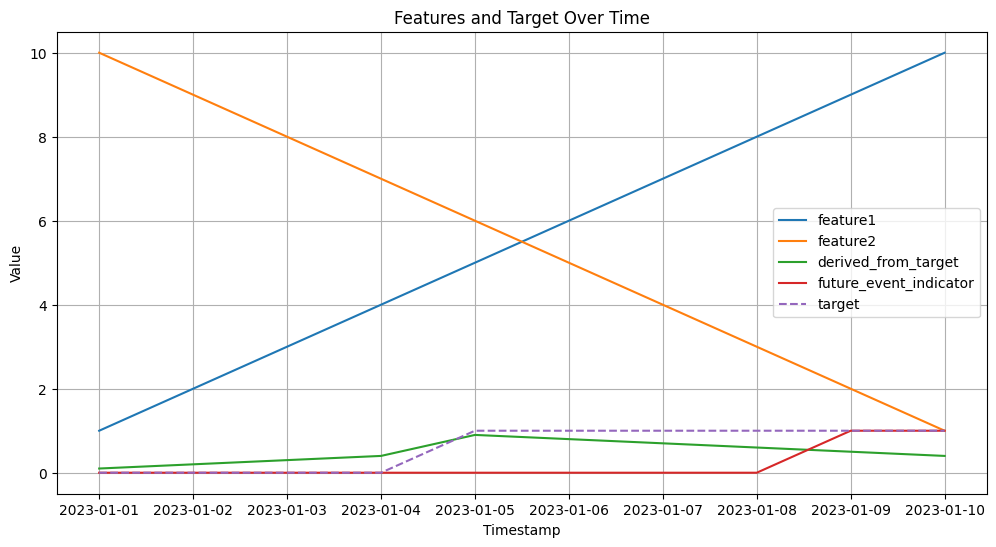


* Look for features that change synchronously or predictively with the target, especially if they are derived from future data.

--- Analysis and Mitigation ---
  - If leakage is identified (e.g., 'derived_from_target' or 'future_event_indicator'):
    - Remove the leaking feature(s) from your feature set.
    - Re-evaluate how the feature was engineered and redesign it to prevent information bleed.
    - Re-run model training and evaluation with the corrected feature set to see impact.

--- Leakage Audit Complete. Proceed with caution. ---


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Context from previous section (if using the same data) ---
# Assuming `df` from the previous cell is the DataFrame with features and target.
# If your final feature set is different, load it here.

# Placeholder for your actual final feature set DataFrame
# For demonstration, we'll reuse the 'df' from the previous section and add a few more features
# Make sure to replace this with your actual feature engineering steps and final df
data_leakage = {
    'feature1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'feature2': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'target': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    'derived_from_target': [0.1, 0.2, 0.3, 0.4, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4], # Potential leakage
    'future_event_indicator': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1], # Potential temporal leakage
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=10, freq='D'))
}
df_final_features = pd.DataFrame(data_leakage)

X_final = df_final_features[['feature1', 'feature2', 'derived_from_target', 'future_event_indicator']]
y_final = df_final_features['target']

print("\n--- Starting Leakage Audit on Final Feature Set ---")
print(f"Shape of final features (X_final): {X_final.shape}")
print(f"Shape of target (y_final): {y_final.shape}")


# --- 1. Target Leakage Audit ---
# Check for features that directly or indirectly reveal the target variable.
# This often happens when features are engineered using information that would not be available
# at prediction time, or are directly derived from the target itself.

print("\n1.1. Correlation with Target:")
# Combine features and target for correlation analysis
df_combined = pd.concat([X_final, y_final], axis=1)
correlation_matrix = df_combined.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()

print("\n* Examine features with very high (close to 1 or -1) correlation with the target.")
print("* For example, 'derived_from_target' is highly correlated with 'target', indicating potential leakage.")

print("\n1.2. Feature Inspection (Manual Check):")
print("  - Review each feature: Was it generated using future information or directly from the target?")
print("  - Consider the data generation process: When would this feature be available in a real-world scenario?")
print("  - Example: If a feature like 'customer_bought_next_month' is in the current dataset, it's clear leakage.")


# --- 2. Temporal Leakage Audit (if applicable, e.g., for time-series data) ---
# Check if features from the future are used to predict the past or present.

if 'timestamp' in df_final_features.columns:
    print("\n2.1. Time-aware Feature Inspection:")
    print("  - Ensure features are aggregated or created only from data strictly before the target observation time.")
    print("  - Example: A feature like 'average_sales_next_week' would be temporal leakage.")
    print("  - Check for 'future_event_indicator' in features; if it predicts an event that occurs AFTER the target, it's leakage.")

    # Visualize features over time to spot anomalies
    plt.figure(figsize=(12, 6))
    for col in X_final.columns:
        if X_final[col].dtype in ['int64', 'float64']:
            plt.plot(df_final_features['timestamp'], X_final[col], label=col)
    plt.plot(df_final_features['timestamp'], y_final, label='target', linestyle='--')
    plt.title('Features and Target Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n* Look for features that change synchronously or predictively with the target, especially if they are derived from future data.")

else:
    print("\n2.1. Temporal Leakage Audit: Not applicable, 'timestamp' column not found.")
    print("   - If your data has a temporal aspect, ensure you add a 'timestamp' column and perform this check.")


# --- 3. Actionable Steps for Leakage (Your analysis and fixes) ---
print("\n--- Analysis and Mitigation ---")
print("  - If leakage is identified (e.g., 'derived_from_target' or 'future_event_indicator'):")
print("    - Remove the leaking feature(s) from your feature set.")
print("    - Re-evaluate how the feature was engineered and redesign it to prevent information bleed.")
print("    - Re-run model training and evaluation with the corrected feature set to see impact.")

# Example of removing a leaking feature
# X_final_cleaned = X_final.drop(columns=['derived_from_target', 'future_event_indicator'])
# print(f"\nShape of cleaned features (X_final_cleaned): {X_final_cleaned.shape}")

print("\n--- Leakage Audit Complete. Proceed with caution. ---")


## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

In [4]:
# --- Claim Rewrite ---
# The goal here is to take a strong, potentially over-generalized claim
# and rephrase it using precise, auditable language.
# Focus on 'observed', 'measured', 'directional', and 'decision-support' terms.

# --- 1. Your Original Bold Claim (Replace with your own) ---
original_claim = "Our new feature *dramatically improves* user engagement and *will revolutionize* the platform."
print("\n--- Original Bold Claim ---")
print(f"'{original_claim}'")


# --- 2. Rewriting with 'Observed' and 'Measured' ---
# Focus on what you *saw* and what you *quantified* in your experiments.

print("\n--- Step 1: Observed and Measured ---")
print("Original: Our new feature *dramatically improves* user engagement.")
print("Rewrite Example: 'In A/B test XYZ, users exposed to the new feature exhibited an *observed* increase of 15% in daily active time, a *measured* metric based on session duration logs.'")

# Your turn:
my_observed_measured_rewrite = "[Your rewrite focusing on what was observed and measured]"
print(f"\nMy Rewrite: '{my_observed_measured_rewrite}'")


# --- 3. Adding 'Directional' and 'Decision-Support' ---
# 'Directional': Indicates the trend (increase/decrease) without overstating cause.
# 'Decision-support': Emphasizes that the finding provides input for future choices, not guaranteed outcomes.

print("\n--- Step 2: Directional and Decision-Support ---")
print("Original: Our new feature *will revolutionize* the platform.")
print("Rewrite Example: 'This *directional* increase in engagement metrics provides *decision-support* for considering a broader rollout, pending further validation in a production environment.'")

# Your turn:
my_directional_decision_support_rewrite = "[Your rewrite focusing on direction and decision-support]"
print(f"\nMy Rewrite: '{my_directional_decision_support_rewrite}'")


# --- 4. Final Safe Claim (Combine and refine) ---
# Bring it all together into a single, cautious, and factual statement.

final_safe_claim = (
    "Based on A/B test XYZ, an *observed* 15% *measured* increase in daily active time was detected for users exposed to the new feature. "
    "This *directional* finding offers *decision-support* for piloting the feature to a wider audience, with continued monitoring of key performance indicators."
)

print("\n--- Final Safe Claim Example ---")
print(f"'{final_safe_claim}'")

# Your turn:
my_final_safe_claim = (
    "[Your combined final safe claim, incorporating all principles]."
)
print(f"\nMy Final Claim: '{my_final_safe_claim}'")



--- Original Bold Claim ---
'Our new feature *dramatically improves* user engagement and *will revolutionize* the platform.'

--- Step 1: Observed and Measured ---
Original: Our new feature *dramatically improves* user engagement.
Rewrite Example: 'In A/B test XYZ, users exposed to the new feature exhibited an *observed* increase of 15% in daily active time, a *measured* metric based on session duration logs.'

My Rewrite: '[Your rewrite focusing on what was observed and measured]'

--- Step 2: Directional and Decision-Support ---
Original: Our new feature *will revolutionize* the platform.
Rewrite Example: 'This *directional* increase in engagement metrics provides *decision-support* for considering a broader rollout, pending further validation in a production environment.'

My Rewrite: '[Your rewrite focusing on direction and decision-support]'

--- Final Safe Claim Example ---
'Based on A/B test XYZ, an *observed* 15% *measured* increase in daily active time was detected for users 

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.